# W&B Sweep — DQN
Búsqueda de hiperparámetros para el agente DQN en el ambiente Simple (CSTR).
- Método: Random Search
- Proyecto W&B: `Tesis_DQN_ORCH`
- Arquitectura: Compleja (ORCH+CTRL)

## 1. Instalación e Imports

In [1]:
import os
import random
import numpy as np
import torch
import wandb
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Clonar desde Github:
!git clone https://github.com/valeriaeskenazi/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning.git
PROJECT_PATH = '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4'
sys.path.append(PROJECT_PATH)

Cloning into 'Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning'...
remote: Enumerating objects: 1451, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 1451 (delta 3), reused 8 (delta 2), pack-reused 1440 (from 1)
Receiving objects: 100% (1451/1451), 32.13 MiB | 18.80 MiB/s, done.
Resolving deltas: 100% (867/867), done.


In [21]:
from Environment.Simulation_Env.Reactor_CSTR import CSTRSimulator
from Environment.PIDControlEnv_simple import PIDControlEnv_Simple
from Environment.PIDControlEnv_complex import PIDControlEnv_Complex
from Agente.DQN.train_DQN import DQNTrainer
from Agente.DQN.algorithm_DQN import DQNAgent
from Aux.Plots import SimplePlotter, print_summary

print('Imports completados')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

Imports completados
PyTorch: 2.10.0+cpu
Device: CPU


In [4]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

/bin/bash: line 1: nvidia-smi: command not found


## 2. Login W&B

In [5]:
!pip install wandb --quiet

In [6]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: ve326684 (ve326684-universidad-ort-uruguay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 3. Configuración del Sweep

In [10]:
WANDB_TEAM    = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_DQN_ORCH'

sweep_config = {
    'name':   'dqn_cstr_random_search_orch',
    'method': 'random',

    'metric': {
        'name': 'eval_reward',
        'goal': 'maximize'
    },

    'parameters': {

        # ============ AMBIENTE ============
        'max_time_detector': {'values': [15, 30]},
        'max_steps'         : {'values': [20, 50]},
        'reward_dead_band'  : {'values': [0.02, 0.05]},
        'delta_percent_orch': {'values': [0.05, 0.1]},

        # Reward weights — combinaciones predefinidas
        'reward_weights_idx': {'values': [0, 1, 2]},

        # ============ AGENTE DQN ============
        'lr'                : {'values': [1e-5, 1e-4]},          # saco el 1e-3, fue inestable
        'hidden_dims_idx'   : {'values': [0, 1]},                # (64,32) y (128,64), el orch es simple
        'epsilon_decay'     : {'values': [0.9995, 0.9999]},      # decay lento, 300ep es poco
        'batch_size'        : {'values': [32, 64]},              # saco 128, buffer chico no lo justifica
        'buffer_type'       : {'values': ['priority', 'simple']},# quiero seguir probando ambos
        'buffer_size'       : {'values': [5000, 10000]},
        'target_update_freq': {'values': [50, 100]},
    }
}

sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT, entity=WANDB_TEAM)
print(f'Sweep creado: {sweep_id}')

Create sweep with ID: rbg0jowk
Sweep URL: https://wandb.ai/ve326684-universidad-ort-uruguay/Tesis_DQN_ORCH/sweeps/rbg0jowk
Sweep creado: rbg0jowk


## 4. Función de Entrenamiento

In [11]:
# ============ LISTAS DE OPCIONES PREDEFINIDAS ============

REWARD_WEIGHTS_OPTIONS = [
    {'error': 1.0, 'tiempo': 0.3, 'overshoot': 0.2, 'energy': 0.1},   # 0: balanceado (default)
    {'error': 2.0, 'tiempo': 0.1, 'overshoot': 0.5, 'energy': 0.1},   # 1: foco en error y overshoot
    {'error': 1.0, 'tiempo': 0.5, 'overshoot': 0.1, 'energy': 0.5},   # 2: foco en tiempo y energía
]

HIDDEN_DIMS_OPTIONS = [
    (64, 32),
    (128, 64)
]

# ============ FIJOS PARA TODOS LOS RUNS ============
SEED             = 42
N_EPISODES       = 300
EVAL_FREQUENCY   = 50
EARLY_STOPPING_PATIENCE      = 10
EARLY_STOPPING_MIN_DELTA_PCT = 0.01
DT               = 1.0
DEVICE           = 'cuda' if torch.cuda.is_available() else 'cpu'

# Variables manipulables (las controla ctrl, fijas)
N_MANIPULABLE_VARS = 2
MANIPULABLE_RANGES = [(300, 420), (99.5, 102)]

# Variable objetivo (la optimiza orch)
N_TARGET_VARS         = 1
TARGET_RANGES         = [(0.0, 1.0)]
TARGET_SETPOINTS      = [0.4]          # Cb objetivo del paper
TARGET_WORKING_RANGES = [(0.0, 2.0)]   # rango físico del CSTR

# Checkpoint del ctrl pre-entrenado
CTRL_CHECKPOINT = '/content/Checkpoints/agent_ctrl_best.pt'


def sweep_run():
    wandb.init()
    cfg = wandb.config

    random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False
    wandb.config.update({'seed': SEED}, allow_val_change=True)

    reward_weights = REWARD_WEIGHTS_OPTIONS[cfg.reward_weights_idx]
    hidden_dims    = HIDDEN_DIMS_OPTIONS[cfg.hidden_dims_idx]
    wandb.config.update({
        'reward_weights': str(reward_weights),
        'hidden_dims':    str(hidden_dims),
    }, allow_val_change=True)

    cstr = CSTRSimulator(dt=DT, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))

    trainer_config = {
        'env_config': {
            'architecture'        : 'jerarquica',
            'env_type'            : 'simulation',
            'n_manipulable_vars'  : N_MANIPULABLE_VARS,
            'manipulable_ranges'  : MANIPULABLE_RANGES,
            'n_target_vars'       : N_TARGET_VARS,
            'target_ranges'       : TARGET_RANGES,
            'target_setpoints'    : TARGET_SETPOINTS,
            'target_working_ranges': TARGET_WORKING_RANGES,
            'dt_usuario'          : DT,
            'max_steps'           : cfg.max_steps,
            'max_time_detector'   : cfg.max_time_detector,
            'reward_dead_band'    : cfg.reward_dead_band,
            'delta_percent_ctrl'  : 0.3,        # fijo, del ctrl entrenado
            'delta_percent_orch'  : cfg.delta_percent_orch,
            'reward_weights'      : reward_weights,
            'pid_limits'          : [(0.01, 5.0), (0.001, 1.0), (0.0001, 1.0)],
            'agent_orchestrator_config': {'agent_type': 'discrete'},
            'env_type_config'     : {'dt': DT, 'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])},
            'stability_config'    : {
                'error_increase_tolerance': 2.0,
                'max_sign_changes_ratio'  : 0.2,
                'max_abrupt_change_ratio' : 0.03,
                'abrupt_change_threshold' : 0.3,
            },
        },

        'ctrl_checkpoint_path': CTRL_CHECKPOINT,
        'agent_ctrl_config': {
            'state_dim'  : N_MANIPULABLE_VARS * 5,
            'action_dim' : 7,
            'n_vars'     : N_MANIPULABLE_VARS,
            'action_type': 'discrete',
            'hidden_dims': (128, 64),   # fijo, el del ctrl entrenado
            'device'     : DEVICE,
        },

        'agent_orch_config': {
            'state_dim'         : N_TARGET_VARS * 5,
            'action_dim'        : 3,
            'n_vars'            : N_MANIPULABLE_VARS,
            'hidden_dims'       : hidden_dims,
            'lr'                : cfg.lr,
            'gamma'             : 0.99,
            'epsilon_start'     : 1.0,
            'epsilon_min'       : 0.01,
            'epsilon_decay'     : cfg.epsilon_decay,
            'batch_size'        : cfg.batch_size,
            'target_update_freq': cfg.target_update_freq,
            'buffer_type'       : cfg.buffer_type,
            'buffer_size'       : cfg.buffer_size,
            'device'            : DEVICE,
            'seed'              : SEED,
        },

        'n_episodes'                 : N_EPISODES,
        'eval_frequency'             : EVAL_FREQUENCY,
        'save_frequency'             : 9999,
        'log_frequency'              : 50,
        'checkpoint_dir'             : f'checkpoints/orch_{wandb.run.name}',
        'early_stopping_patience'    : EARLY_STOPPING_PATIENCE,
        'early_stopping_min_delta_pct': EARLY_STOPPING_MIN_DELTA_PCT,
        'use_wandb': True,
    }

    trainer = DQNTrainer(trainer_config)
    trainer.env.proceso.connect_external_process(cstr)
    trainer.train()

    wandb.log({
        'final_eval_reward'      : trainer.best_reward,
        'total_episodes'         : len(trainer.episode_rewards),
        'final_epsilon'          : trainer.epsilons[-1] if trainer.epsilons else 0,
        'final_reward_mean10'    : np.mean(trainer.episode_rewards[-10:]),
        'final_energy_mean10'    : np.mean(trainer.episode_energies[-10:]),
        'final_overshoot_mean10' : np.mean(trainer.episode_max_overshoots[-10:]),
    })

    run_name = wandb.run.name
    wandb.finish()
    print(f'Run completado: {run_name}')


## 5. Lanzar Sweep

In [10]:
wandb.agent(sweep_id, function=sweep_run, count=30)

wandb: Agent Starting Run: m3sx3ut9 with config:
wandb: 	batch_size: 32
wandb: 	buffer_size: 10000
wandb: 	buffer_type: priority
wandb: 	delta_percent_orch: 0.05
wandb: 	epsilon_decay: 0.9999
wandb: 	hidden_dims_idx: 0
wandb: 	lr: 1e-05
wandb: 	max_steps: 50
wandb: 	max_time_detector: 30
wandb: 	reward_dead_band: 0.02
wandb: 	reward_weights_idx: 1
wandb: 	target_update_freq: 50
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Cargando agente CTRL pre-entrenado desde: /content/Checkpoints/agent_ctrl_best.pt

Episodio 0/300
  Reward: -4.00
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 222.3645
  ORCH Epsilon: 0.9981

Episodio 50/300
  Reward: -0.40
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 6.6019
  ORCH Epsilon: 0.7773
Evaluación: Reward promedio = -1.21
Agente guardado en: checkpoints/orch_breezy-sweep-4/agent_ctrl_best.pt
Agente guardado en: checkpoints/orch_breezy-sweep-4/agent_orch_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -4.24
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 1.9216
  ORCH Epsilon: 0.6054
Evaluación: Reward promedio = -1.13
Agente guardado en: checkpoints/orch_breezy-sweep-4/agent_ctrl_best.pt
Agente guardado en: checkpoints/orch_breezy-sweep-4/agent_orch_best.pt
Checkpoint guardado: best

Episodio 150/300
  Reward: -2.00
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 2.7891
  

energy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epsilon,█████▇▇▇▆▆▆▅▅▅▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁
eval_reward,██▁▄▅
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
loss,█▅▅▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overshoot,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/wandb/agents/pyagent.py", line 304, in _run_job
    self._function()
  File "/tmp/ipykernel_13861/174803881.py", line 137, in sweep_run
    print(f'Run completado: {wandb.run.name}')
                             ^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'name'

wandb: ERROR Run m3sx3ut9 errored: 'NoneType' object has no attribute 'name'
wandb: Agent Starting Run: qe1n0yk6 with config:
wandb: 	batch_size: 64
wandb: 	buffer_size: 5000
wandb: 	buffer_type: priority
wandb: 	delta_percent_orch: 0.05
wandb: 	epsilon_decay: 0.9999
wandb: 	hidden_dims_idx: 0
wandb: 	lr: 0.0001
wandb: 	max_steps: 20
wandb: 	max_time_detector: 15
wandb: 	reward_dead_band: 0.02
wandb: 	reward_weights_idx: 1
wandb: 	target_update_freq: 50
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Cargando agente CTRL pre-entrenado desde: /content/Checkpoints/agent_ctrl_best.pt

Episodio 0/300
  Reward: -3.97
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0.0000
  ORCH Epsilon: 1.0000

Episodio 50/300
  Reward: -1.13
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 5.6187
  ORCH Epsilon: 0.9087
Evaluación: Reward promedio = -1.17
Agente guardado en: checkpoints/orch_serene-sweep-5/agent_ctrl_best.pt
Agente guardado en: checkpoints/orch_serene-sweep-5/agent_orch_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -0.86
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 4.9222
  ORCH Epsilon: 0.8223
Evaluación: Reward promedio = -1.03
Agente guardado en: checkpoints/orch_serene-sweep-5/agent_ctrl_best.pt
Agente guardado en: checkpoints/orch_serene-sweep-5/agent_orch_best.pt
Checkpoint guardado: best

Episodio 150/300
  Reward: -1.28
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 2.0733
  OR

...

energy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epsilon,██▇▇▇▇▇▆▅▅▅▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,██▂▇▁
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
loss,█▇▂▂▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂
overshoot,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/wandb/agents/pyagent.py", line 304, in _run_job
    self._function()
  File "/tmp/ipykernel_13861/174803881.py", line 137, in sweep_run
    print(f'Run completado: {wandb.run.name}')
                             ^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'name'

wandb: ERROR Run 3ikzp30c errored: 'NoneType' object has no attribute 'name'
wandb: Agent Starting Run: yir189dr with config:
wandb: 	batch_size: 64
wandb: 	buffer_size: 5000
wandb: 	buffer_type: simple
wandb: 	delta_percent_orch: 0.1
wandb: 	epsilon_decay: 0.9999
wandb: 	hidden_dims_idx: 1
wandb: 	lr: 0.0001
wandb: 	max_steps: 20
wandb: 	max_time_detector: 30
wandb: 	reward_dead_band: 0.05
wandb: 	reward_weights_idx: 0
wandb: 	target_update_freq: 100
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Cargando agente CTRL pre-entrenado desde: /content/Checkpoints/agent_ctrl_best.pt

Episodio 0/300
  Reward: -2.02
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0.0000
  ORCH Epsilon: 1.0000

Episodio 50/300
  Reward: -0.66
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0.4383
  ORCH Epsilon: 0.9087
Evaluación: Reward promedio = -0.44
Agente guardado en: checkpoints/orch_likely-sweep-9/agent_ctrl_best.pt
Agente guardado en: checkpoints/orch_likely-sweep-9/agent_orch_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -0.62
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0.8330
  ORCH Epsilon: 0.8223
Evaluación: Reward promedio = -0.47
  Sin mejora: 1/10

Episodio 150/300
  Reward: -0.97
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 1.0098
  ORCH Epsilon: 0.7440
Evaluación: Reward promedio = -0.61
  Sin mejora: 2/10

Episodio 200/300
  Reward: -0.68
  Length: 20
  CTRL Loss: 0.0000
  CTRL E

energy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epsilon,█████▇▇▇▆▆▆▆▆▆▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁
eval_reward,█▇▁▅▁
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
loss,▁█▅▃▁▁▁▁▂▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
overshoot,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/wandb/agents/pyagent.py", line 304, in _run_job
    self._function()
  File "/tmp/ipykernel_13861/174803881.py", line 137, in sweep_run
    print(f'Run completado: {wandb.run.name}')
                             ^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'name'

wandb: ERROR Run yir189dr errored: 'NoneType' object has no attribute 'name'
wandb: ERROR Detected 5 failed runs in a row at start, killing sweep.
wandb: To change this value set WANDB_AGENT_MAX_INITIAL_FAILURES=val


Se me corto por un error en el nombre, largo 21 runs mas

In [12]:
wandb.agent(sweep_id, function=sweep_run, count=21)

wandb: Agent Starting Run: fxxhqwil with config:
wandb: 	batch_size: 64
wandb: 	buffer_size: 10000
wandb: 	buffer_type: simple
wandb: 	delta_percent_orch: 0.05
wandb: 	epsilon_decay: 0.9999
wandb: 	hidden_dims_idx: 1
wandb: 	lr: 1e-05
wandb: 	max_steps: 20
wandb: 	max_time_detector: 15
wandb: 	reward_dead_band: 0.02
wandb: 	reward_weights_idx: 1
wandb: 	target_update_freq: 50
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Cargando agente CTRL pre-entrenado desde: /content/Checkpoints/agent_ctrl_best.pt

Episodio 0/300
  Reward: -3.97
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0.0000
  ORCH Epsilon: 1.0000

Episodio 50/300
  Reward: -0.61
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 2.9243
  ORCH Epsilon: 0.9087
Evaluación: Reward promedio = -0.97
Agente guardado en: checkpoints/orch_northern-sweep-10/agent_ctrl_best.pt
Agente guardado en: checkpoints/orch_northern-sweep-10/agent_orch_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -1.14
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 5.2661
  ORCH Epsilon: 0.8223
Evaluación: Reward promedio = -1.33
  Sin mejora: 1/10

Episodio 150/300
  Reward: -1.07
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 7.3388
  ORCH Epsilon: 0.7440
Evaluación: Reward promedio = -1.46
  Sin mejora: 2/10

Episodio 200/300
  Reward: -1.48
  Length: 20
  CTRL Loss: 0.0000
  

energy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epsilon,█████▇▇▆▆▆▅▅▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁
eval_reward,█▅▄▇▁
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
loss,▄▄▂▂▂▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▅▅█▆▇▇▅
overshoot,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


Run completado: northern-sweep-10


wandb: Agent Starting Run: bm8f85i6 with config:
wandb: 	batch_size: 64
wandb: 	buffer_size: 10000
wandb: 	buffer_type: priority
wandb: 	delta_percent_orch: 0.05
wandb: 	epsilon_decay: 0.9999
wandb: 	hidden_dims_idx: 0
wandb: 	lr: 1e-05
wandb: 	max_steps: 20
wandb: 	max_time_detector: 15
wandb: 	reward_dead_band: 0.02
wandb: 	reward_weights_idx: 0
wandb: 	target_update_freq: 50
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


...

Run completado: classic-sweep-29


wandb: Agent Starting Run: 27filux3 with config:
wandb: 	batch_size: 64
wandb: 	buffer_size: 5000
wandb: 	buffer_type: priority
wandb: 	delta_percent_orch: 0.1
wandb: 	epsilon_decay: 0.9995
wandb: 	hidden_dims_idx: 0
wandb: 	lr: 0.0001
wandb: 	max_steps: 20
wandb: 	max_time_detector: 30
wandb: 	reward_dead_band: 0.05
wandb: 	reward_weights_idx: 2
wandb: 	target_update_freq: 100
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Cargando agente CTRL pre-entrenado desde: /content/Checkpoints/agent_ctrl_best.pt

Episodio 0/300
  Reward: -2.23
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0.0000
  ORCH Epsilon: 1.0000

Episodio 50/300
  Reward: -1.52
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0.6041
  ORCH Epsilon: 0.6196
Evaluación: Reward promedio = -1.88
Agente guardado en: checkpoints/orch_legendary-sweep-30/agent_ctrl_best.pt
Agente guardado en: checkpoints/orch_legendary-sweep-30/agent_orch_best.pt
Checkpoint guardado: best

Episodio 100/300
  Reward: -1.49
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0.7425
  ORCH Epsilon: 0.3758
Evaluación: Reward promedio = -0.77
Agente guardado en: checkpoints/orch_legendary-sweep-30/agent_ctrl_best.pt
Agente guardado en: checkpoints/orch_legendary-sweep-30/agent_orch_best.pt
Checkpoint guardado: best

Episodio 150/300
  Reward: -1.38
  Length: 20
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH L

energy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epsilon,███▇▇▆▆▆▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
eval_reward,▁▆▄▇█
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
loss,█▅▂▃▃▃▄▅▄▂▃▂▂▃▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁
overshoot,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


Run completado: legendary-sweep-30


### 5.1 Visualización local del mejor run


In [14]:
api = wandb.Api()
runs_all = api.runs('ve326684-universidad-ort-uruguay/Tesis_DQN_ORCH')
runs_orch = [r for r in runs_all if r.state == 'finished']
print(len(runs_orch), 'runs finished')

rows = []
for r in runs_orch:
    s = dict(r.summary)
    rows.append({
        'name'        : r.name,
        'id'          : r.id,
        'reward'      : s.get('reward'),
        'eval_reward' : s.get('eval_reward'),
        'loss'        : s.get('loss'),
    })

df_orch = pd.DataFrame(rows).sort_values('eval_reward', ascending=False)
print(df_orch.to_string())

27 runs finished
                  name        id    reward  eval_reward       loss
25    classic-sweep-29  dhz3tl1r -0.320235    -0.191779   0.042479
8     ancient-sweep-12  e27ler4b -0.125506    -0.204121   0.054026
26  legendary-sweep-30  27filux3 -0.660716    -0.284299   0.129275
23    curious-sweep-27  ut87l58z -0.593924    -0.441096   0.151592
2       earthy-sweep-6  65gnstog -0.589158    -0.454999   0.259409
16  glamorous-sweep-20  s21m660w -0.431497    -0.480948   0.198195
10       firm-sweep-14  mlbmp8ra -0.518098    -0.482448   7.040556
22    flowing-sweep-26  pe9hhvnk -1.560629    -0.589080   7.437116
24     autumn-sweep-28  a0a1lp14 -0.737048    -0.600800   2.356136
5       likely-sweep-9  yir189dr -0.694426    -0.618564   0.485448
1       serene-sweep-5  qe1n0yk6 -0.952564    -0.688403   0.296219
13      super-sweep-17  3oxqf1xg -1.295457    -0.794065   1.057358
19  visionary-sweep-23  93sqis05 -1.115985    -0.873555  21.644093
18  different-sweep-22  kg6kibm1 -0.534743   

In [15]:
for run_id in ['dhz3tl1r', 'e27ler4b']:
    r = api.run(f've326684-universidad-ort-uruguay/Tesis_DQN_ORCH/{run_id}')
    print(r.name, '|', r.config)
    print()

classic-sweep-29 | {'lr': 0.0001, 'seed': 42, 'max_steps': 50, 'batch_size': 32, 'buffer_size': 5000, 'buffer_type': 'priority', 'hidden_dims': '(64, 32)', 'epsilon_decay': 0.9999, 'reward_weights': "{'error': 1.0, 'tiempo': 0.3, 'overshoot': 0.2, 'energy': 0.1}", 'hidden_dims_idx': 0, 'reward_dead_band': 0.05, 'max_time_detector': 15, 'delta_percent_orch': 0.05, 'reward_weights_idx': 0, 'target_update_freq': 100}

ancient-sweep-12 | {'lr': 0.0001, 'seed': 42, 'max_steps': 50, 'batch_size': 32, 'buffer_size': 10000, 'buffer_type': 'priority', 'hidden_dims': '(128, 64)', 'epsilon_decay': 0.9995, 'reward_weights': "{'error': 1.0, 'tiempo': 0.3, 'overshoot': 0.2, 'energy': 0.1}", 'hidden_dims_idx': 1, 'reward_dead_band': 0.02, 'max_time_detector': 15, 'delta_percent_orch': 0.1, 'reward_weights_idx': 0, 'target_update_freq': 50}



## 7. Lanzar sweep por 15000 episdoiso del mejor run anterior

In [16]:

WANDB_ENTITY  = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_DQN_ORCH'
RUN_NAME      = 'orch_postfix_15k'
CTRL_CHECKPOINT = '/content/Checkpoints/agent_ctrl_best.pt'

N_EPISODES               = 15000
EVAL_FREQUENCY           = 100
LOG_FREQUENCY            = 100
SAVE_FREQUENCY           = 2000
EARLY_STOPPING_PATIENCE  = 50
EARLY_STOPPING_MIN_DELTA_PCT = 0.01
SEED                     = 42
DEVICE                   = 'cuda' if torch.cuda.is_available() else 'cpu'

MANIPULABLE_RANGES = [(300, 420), (99.5, 102)]

trainer_config = {
    'env_config': {
        'architecture'        : 'jerarquica',
        'env_type'            : 'simulation',
        'n_manipulable_vars'  : 2,
        'manipulable_ranges'  : MANIPULABLE_RANGES,
        'n_target_vars'       : 1,
        'target_ranges'       : [(0.0, 1.0)],
        'target_setpoints'    : [0.4],
        'target_working_ranges': [(0.0, 2.0)],
        'dt_usuario'          : 1.0,
        'max_steps'           : 50,
        'max_time_detector'   : 15,
        'reward_dead_band'    : 0.02,
        'delta_percent_ctrl'  : 0.3,
        'delta_percent_orch'  : 0.1,
        'reward_weights'      : {'error': 1.0, 'tiempo': 0.3, 'overshoot': 0.2, 'energy': 0.1},
        'pid_limits'          : [(0.01, 5.0), (0.001, 1.0), (0.0001, 1.0)],
        'agent_orchestrator_config': {'agent_type': 'discrete'},
        'env_type_config'     : {'dt': 1.0, 'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])},
        'stability_config'    : {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.2,
            'max_abrupt_change_ratio' : 0.03,
            'abrupt_change_threshold' : 0.3,
        },
    },

    'ctrl_checkpoint_path': CTRL_CHECKPOINT,
    'agent_ctrl_config': {
        'state_dim'  : 10,
        'action_dim' : 7,
        'n_vars'     : 2,
        'action_type': 'discrete',
        'hidden_dims': (128, 64),
        'device'     : DEVICE,
    },

    'agent_orch_config': {
        'state_dim'         : 5,
        'action_dim'        : 3,
        'n_vars'            : 2,
        'hidden_dims'       : (128, 64),
        'lr'                : 1e-4,
        'gamma'             : 0.99,
        'epsilon_start'     : 1.0,
        'epsilon_min'       : 0.01,
        'epsilon_decay'     : 0.9995,
        'batch_size'        : 32,
        'target_update_freq': 50,
        'buffer_type'       : 'priority',
        'buffer_size'       : 10000,
        'device'            : DEVICE,
        'seed'              : SEED,
    },

    'n_episodes'                 : N_EPISODES,
    'eval_frequency'             : EVAL_FREQUENCY,
    'log_frequency'              : LOG_FREQUENCY,
    'save_frequency'             : SAVE_FREQUENCY,
    'checkpoint_dir'             : f'checkpoints/{RUN_NAME}',
    'early_stopping_patience'    : EARLY_STOPPING_PATIENCE,
    'early_stopping_min_delta_pct': EARLY_STOPPING_MIN_DELTA_PCT,
    'use_wandb': True,
}

# Reproducibilidad
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# Init W&B
wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    name    = RUN_NAME,
    tags    = ['post-fix', 'orch', '15k', 'produccion'],
    config  = trainer_config,
)

# Entrenar
cstr = CSTRSimulator(dt=1.0, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))
trainer = DQNTrainer(trainer_config)
trainer.env.proceso.connect_external_process(cstr)
trainer.train()

# Guardar pesos en W&B
import os
checkpoint_path = f'checkpoints/{RUN_NAME}'
if os.path.exists(checkpoint_path):
    artifact = wandb.Artifact(
        name        = f'model_{RUN_NAME}',
        type        = 'model',
        description = 'Pesos ORCH post-fix, 15k episodios'
    )
    artifact.add_dir(checkpoint_path)
    wandb.log_artifact(artifact)
    print('✓ Pesos guardados en W&B')

# Métricas finales
wandb.log({
    'final_eval_reward'      : trainer.best_reward,
    'total_episodes'         : len(trainer.episode_rewards),
    'final_epsilon'          : trainer.epsilons[-1] if trainer.epsilons else 0,
    'final_reward_mean10'    : np.mean(trainer.episode_rewards[-10:]),
    'final_energy_mean10'    : np.mean(trainer.episode_energies[-10:]),
    'final_overshoot_mean10' : np.mean(trainer.episode_max_overshoots[-10:]),
})

run_name = wandb.run.name
wandb.finish()
print(f'Run completado: {run_name}')

Cargando agente CTRL pre-entrenado desde: /content/Checkpoints/agent_ctrl_best.pt

Episodio 0/15000
  Reward: -2.04
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 73.3800
  ORCH Epsilon: 0.9905

Episodio 100/15000
  Reward: -0.51
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0.4971
  ORCH Epsilon: 0.0813
Evaluación: Reward promedio = -0.48
Agente guardado en: checkpoints/orch_postfix_15k/agent_ctrl_best.pt
Agente guardado en: checkpoints/orch_postfix_15k/agent_orch_best.pt
Checkpoint guardado: best

Episodio 200/15000
  Reward: -0.84
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0.3403
  ORCH Epsilon: 0.0100
Evaluación: Reward promedio = -0.34
Agente guardado en: checkpoints/orch_postfix_15k/agent_ctrl_best.pt
Agente guardado en: checkpoints/orch_postfix_15k/agent_orch_best.pt
Checkpoint guardado: best

Episodio 300/15000
  Reward: -0.06
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0.1065
  ORCH

wandb: Adding directory to artifact (checkpoints/orch_postfix_15k)... Done. 0.0s


Evaluación: Reward promedio = -0.34
  Sin mejora: 50/50
Early stopping en episodio 9600
✓ Pesos guardados en W&B


energy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epsilon,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,▁▄▅▅▅▄▄▅▃▇▇▅▄▆▇▇▆▆▄▆▆█▅▄▃▇▄▇▇▅▇▄▃▇▆▃▅▇▅▄
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
loss,▁▁▂▃▃▂▂▄▆█▅▃▄▇▄▁▂▂▃▂▁▂▂▂▂▂▂▂▂▁▂▂▂▂▂▂▁▁▁▁
overshoot,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


Run completado: orch_postfix_15k


Analisis de resultados

In [18]:
r = api.run('ve326684-universidad-ort-uruguay/Tesis_DQN_ORCH/27filux3')
hist = list(r.scan_history())
print(len(hist), 'steps')
print(list(pd.DataFrame(hist).columns))

9901 steps
['final_epsilon', 'loss', '_timestamp', '_step', 'reward', 'final_reward_mean10', 'final_eval_reward', 'energy', 'eval_reward', '_runtime', 'final_overshoot_mean10', 'final_energy_mean10', 'epsilon', 'total_episodes', 'overshoot']


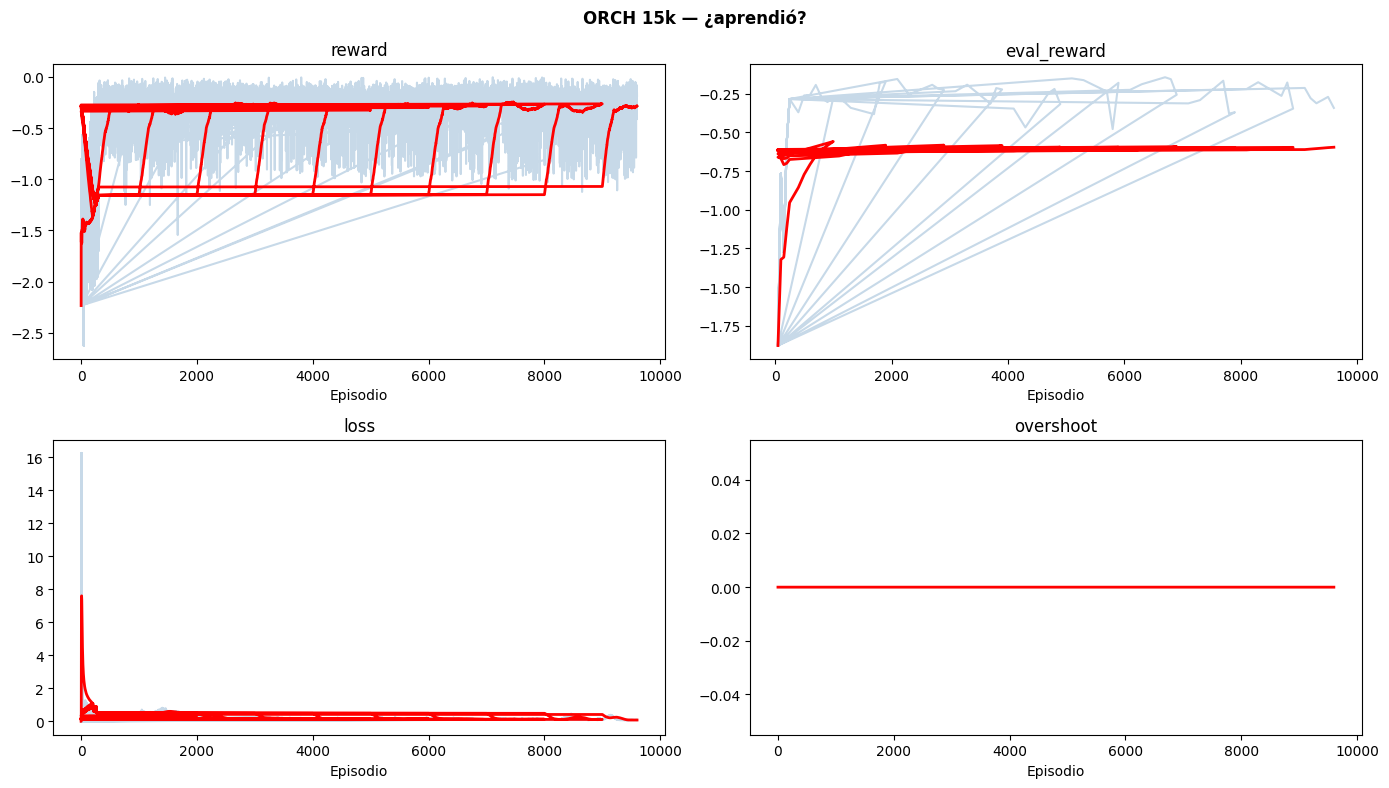

In [19]:
df_orch = pd.DataFrame(hist)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
metricas = ['reward', 'eval_reward', 'loss', 'overshoot']

for ax, col in zip(axes.flat, metricas):
    d = df_orch[['_step', col]].dropna()
    ax.plot(d['_step'], d[col], alpha=0.3, color='steelblue')
    ax.plot(d['_step'], d[col].rolling(200, min_periods=1).mean(), color='red', lw=2)
    ax.set_title(col)
    ax.set_xlabel('Episodio')

plt.suptitle('ORCH 15k — ¿aprendió?', fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
from Agente.DQN.algorithm_DQN import DQNAgent

In [24]:
# ── Cargar CTRL ────────────────────────────────────────────────────────────────
agent_ctrl = DQNAgent(state_dim=10, action_dim=7, n_vars=2, agent_role='ctrl',
                      hidden_dims=(128, 64), device='cpu', seed=42)
agent_ctrl.load('/content/Checkpoints/agent_ctrl_best.pt')
agent_ctrl.epsilon = 0.0

# ── Cargar ORCH ────────────────────────────────────────────────────────────────
agent_orch = DQNAgent(state_dim=5, action_dim=3, n_vars=2, agent_role='orch',
                      hidden_dims=(128, 64), device='cpu', seed=42)
agent_orch.load('/content/checkpoints/orch_postfix_15k/agent_orch_best.pt')
agent_orch.epsilon = 0.0

print('Ambos agentes cargados')

NameError: name 'DQNAgent' is not defined

In [24]:
cstr.reset()
for pid in pid_controllers:
    pid.reset()

current_sps    = [cstr.T_ss, cstr.V_ss]
pvs            = [cstr.T_ss, cstr.V_ss]
error_integral = [0.0, 0.0]
error_prev     = [0.0, 0.0]

# Para el orch
cb_error_integral   = 0.0
cb_error_prev       = 0.0

traj_T, traj_V, traj_Cb = [pvs[0]], [pvs[1]], [float(cstr.state[1])]
traj_sp_T, traj_sp_V    = [current_sps[0]], [current_sps[1]]

for step in range(100):
    # ── ORCH ──────────────────────────────────────────────────────────────────
    Cb_actual         = float(cstr.state[1])
    cb_error          = Cb_target - Cb_actual
    cb_error_integral += cb_error          # acumular entre steps
    cb_error_deriv    = cb_error - cb_error_prev
    cb_error_prev     = cb_error

    state_orch = np.array([Cb_actual, Cb_target, cb_error,
                           cb_error_integral, cb_error_deriv], dtype=np.float32)
    action_orch = agent_orch.select_action(state_orch, training=False)

    new_sps = apply_action_orch.translate(
        action=action_orch, agent_type='orch', action_type='discrete',
        current_values=current_sps
    )
    current_sps = new_sps

    # ── CTRL ──────────────────────────────────────────────────────────────────
    errors = [current_sps[i] - pvs[i] for i in range(2)]
    for i in range(2):
        error_integral[i] += errors[i]
    error_derivative = [errors[i] - error_prev[i] for i in range(2)]
    error_prev = errors.copy()

    state_ctrl = np.array([
        pvs[0], current_sps[0], errors[0], error_integral[0], error_derivative[0],
        pvs[1], current_sps[1], errors[1], error_integral[1], error_derivative[1],
    ], dtype=np.float32)
    action_ctrl = agent_ctrl.select_action(state_ctrl, training=False)

    pid_params = apply_action_ctrl.translate(
        action=action_ctrl, agent_type='ctrl', action_type='discrete',
        current_values=[(p.kp, p.ki, p.kd) for p in pid_controllers]
    )
    for i, (kp, ki, kd) in enumerate(pid_params):
        pid_controllers[i].kp = kp
        pid_controllers[i].ki = ki
        pid_controllers[i].kd = kd

    # ── Simular ───────────────────────────────────────────────────────────────
    resultado = detector.estimate(pvs_inicial=pvs, sps=current_sps,
                                  pid_controllers=pid_controllers,
                                  max_time=15, reset_pid=False)
    pvs = resultado['pvs_final']

    traj_T.append(pvs[0]); traj_V.append(pvs[1])
    traj_Cb.append(float(cstr.state[1]))
    traj_sp_T.append(current_sps[0]); traj_sp_V.append(current_sps[1])

    print(f'Step {step+1:3d} | Cb={cstr.state[1]:.4f} (obj=0.4) | T={pvs[0]:.1f} (sp={current_sps[0]:.1f}) | V={pvs[1]:.3f} (sp={current_sps[1]:.3f})')

Step   1 | Cb=0.3529 (obj=0.4) | T=341.9 (sp=359.7) | V=103.167 (sp=102.000)
Step   2 | Cb=0.5408 (obj=0.4) | T=353.0 (sp=359.7) | V=97.663 (sp=99.500)
Step   3 | Cb=0.6189 (obj=0.4) | T=357.2 (sp=359.7) | V=100.670 (sp=99.500)
Step   4 | Cb=0.6431 (obj=0.4) | T=358.7 (sp=359.7) | V=99.472 (sp=99.500)
Step   5 | Cb=0.6543 (obj=0.4) | T=359.4 (sp=359.7) | V=102.744 (sp=102.000)
Step   6 | Cb=0.6534 (obj=0.4) | T=359.3 (sp=359.7) | V=102.252 (sp=102.000)
Step   7 | Cb=0.6534 (obj=0.4) | T=359.3 (sp=359.7) | V=102.252 (sp=102.000)
Step   8 | Cb=0.6534 (obj=0.4) | T=359.3 (sp=359.7) | V=102.252 (sp=102.000)
Step   9 | Cb=0.6534 (obj=0.4) | T=359.3 (sp=359.7) | V=102.252 (sp=102.000)
Step  10 | Cb=0.6534 (obj=0.4) | T=359.3 (sp=359.7) | V=102.252 (sp=102.000)
Step  11 | Cb=0.2921 (obj=0.4) | T=337.2 (sp=323.7) | V=103.144 (sp=102.000)
Step  12 | Cb=0.1659 (obj=0.4) | T=328.8 (sp=323.7) | V=97.665 (sp=99.500)
Step  13 | Cb=0.4207 (obj=0.4) | T=345.8 (sp=356.1) | V=100.722 (sp=99.500)
Step  1

In [28]:
from Environment.PIDControlEnv_complex import PIDControlEnv_Complex

env_config = {
    'architecture'        : 'jerarquica',
    'env_type'            : 'simulation',
    'n_manipulable_vars'  : 2,
    'manipulable_ranges'  : [(300, 420), (99.5, 102)],
    'n_target_vars'       : 1,
    'target_ranges'       : [(0.0, 1.0)],
    'target_setpoints'    : [0.4],
    'target_working_ranges': [(0.0, 2.0)],
    'dt_usuario'          : 1.0,
    'max_steps'           : 200,        # más steps para ver convergencia
    'max_time_detector'   : 15,
    'reward_dead_band'    : 0.02,
    'delta_percent_ctrl'  : 0.3,
    'delta_percent_orch'  : 0.1,
    'reward_weights'      : {'error': 1.0, 'tiempo': 0.3, 'overshoot': 0.2, 'energy': 0.1},
    'pid_limits'          : [(0.01, 5.0), (0.001, 1.0), (0.0001, 1.0)],
    'agent_orchestrator_config': {'agent_type': 'discrete'},
    'env_type_config'     : {'dt': 1.0, 'control_limits': ((300, 420), (99.5, 102))},
    'stability_config'    : {
        'error_increase_tolerance': 2.0,
        'max_sign_changes_ratio'  : 0.2,
        'max_abrupt_change_ratio' : 0.03,
        'abrupt_change_threshold' : 0.3,
    },
}

env = PIDControlEnv_Complex(env_config)
env.agente_ctrl = agent_ctrl
env.action_type_ctrl = 'discrete'

cstr = CSTRSimulator(dt=1.0, control_limits=((300, 420), (99.5, 102)))
env.proceso.connect_external_process(cstr)

# Evaluar
obs, _ = env.reset()
state_orch = obs['orch']

traj_Cb, traj_T, traj_V = [], [], []
traj_sp_T, traj_sp_V    = [], []

done = False
step = 0
while not done and step < 200:
    action_orch = agent_orch.select_action(state_orch, training=False)
    obs, reward, terminated, truncated, info = env.step({'orch': action_orch, 'ctrl': None})
    done = terminated or truncated
    state_orch = obs['orch']

    Cb  = float(cstr.state[1])
    T   = env.manipulable_pvs[0]
    V   = env.manipulable_pvs[1]
    spT = env.current_SPs_manipulable[0]
    spV = env.current_SPs_manipulable[1]

    traj_Cb.append(Cb); traj_T.append(T); traj_V.append(V)
    traj_sp_T.append(spT); traj_sp_V.append(spV)
    step += 1
    print(f'Step {step:3d} | Cb={Cb:.4f} (obj=0.4) | T={T:.1f} (sp={spT:.1f}) | V={V:.3f} (sp={spV:.3f})')

Step   1 | Cb=0.0630 (obj=0.4) | T=316.5 (sp=300.0) | V=99.500 (sp=99.930)
Step   2 | Cb=0.0581 (obj=0.4) | T=316.6 (sp=300.0) | V=99.500 (sp=102.000)
Step   3 | Cb=0.0532 (obj=0.4) | T=316.5 (sp=300.0) | V=99.500 (sp=102.000)
Step   4 | Cb=0.0483 (obj=0.4) | T=316.4 (sp=300.0) | V=99.500 (sp=102.000)
Step   5 | Cb=0.0434 (obj=0.4) | T=316.4 (sp=300.0) | V=99.500 (sp=102.000)
Step   6 | Cb=0.0384 (obj=0.4) | T=316.4 (sp=300.0) | V=99.500 (sp=102.000)
Step   7 | Cb=0.0335 (obj=0.4) | T=316.4 (sp=300.0) | V=99.500 (sp=99.500)
Step   8 | Cb=0.0284 (obj=0.4) | T=316.4 (sp=300.0) | V=99.500 (sp=99.500)
Step   9 | Cb=0.0234 (obj=0.4) | T=316.2 (sp=300.0) | V=99.500 (sp=99.500)
Step  10 | Cb=0.0184 (obj=0.4) | T=316.2 (sp=300.0) | V=99.500 (sp=99.500)
Step  11 | Cb=0.0133 (obj=0.4) | T=316.1 (sp=330.0) | V=99.500 (sp=99.500)
Step  12 | Cb=0.0082 (obj=0.4) | T=316.2 (sp=363.0) | V=99.500 (sp=99.500)
Step  13 | Cb=0.0068 (obj=0.4) | T=316.1 (sp=399.3) | V=99.500 (sp=99.500)
Step  14 | Cb=0.0068

In [43]:
env.agente_ctrl = agent_ctrl
env.action_type_ctrl = 'discrete'
agent_orch.epsilon = 0.0
agent_ctrl.epsilon = 0.0

obs, info = env.reset()
print('Cb inicial:', info['target_pvs'][0])
print('T inicial:', info['manipulable_pvs'][0])
print('V inicial:', info['manipulable_pvs'][1])

Cb inicial: 1.394764874272953
T inicial: 327.0
V inicial: 102.0


In [44]:
cb_traj  = [info['target_pvs'][0]]
T_traj   = [info['manipulable_pvs'][0]]
V_traj   = [info['manipulable_pvs'][1]]
rewards_traj = []

done = False
step = 0

print(f"{'Step':<6} {'Cb':<10} {'T':<10} {'V':<10} {'Reward':<10}")
print("-" * 50)

while not done and step < 50:
    action = agent_orch.select_action(obs['orch'], training=False)
    obs, reward, terminated, truncated, info = env.step({'orch': action, 'ctrl': None})
    done = terminated or truncated

    cb_traj.append(info['target_pvs'][0])
    T_traj.append(info['manipulable_pvs'][0])
    V_traj.append(info['manipulable_pvs'][1])
    rewards_traj.append(reward)

    print(f"{step+1:<6} {info['target_pvs'][0]:<10.4f} {info['manipulable_pvs'][0]:<10.2f} "
          f"{info['manipulable_pvs'][1]:<10.2f} {reward:<10.3f}")
    step += 1

print(f"\nCb final: {cb_traj[-1]:.4f} | Error: {abs(cb_traj[-1]-0.4):.4f} | Reward total: {sum(rewards_traj):.2f}")

Step   Cb         T          V          Reward    
--------------------------------------------------
1      0.0630     316.56     99.50      -0.120    
2      0.0581     316.49     99.50      -0.111    
3      0.0532     316.40     99.50      -0.100    
4      0.0483     316.50     99.50      -0.089    
5      0.0434     316.49     99.50      -0.078    
6      0.0384     316.34     99.50      -0.067    
7      0.0335     316.35     99.50      -0.056    
8      0.0284     316.40     99.50      -0.044    
9      0.0234     316.34     99.50      -0.033    
10     0.0184     316.15     99.50      -0.025    
11     0.0133     316.18     99.50      -0.036    
12     0.0082     316.15     99.50      -0.047    
13     0.0068     316.26     99.50      -0.051    
14     0.0068     316.22     99.50      -0.051    
15     0.0068     316.22     99.50      -0.051    
16     0.0068     316.19     99.50      -0.051    
17     0.0068     316.18     99.50      -0.051    
18     0.0068     316.25     99

In [45]:
obs, info = env.reset()

cb_traj  = [info['target_pvs'][0]]
T_traj   = [info['manipulable_pvs'][0]]
V_traj   = [info['manipulable_pvs'][1]]
rewards_traj = []

done = False
step = 0

print(f"{'Step':<6} {'Cb':<10} {'T':<10} {'V':<10} {'Reward':<10}")
print("-" * 50)

while not done and step < 50:
    # Obtener estado ctrl del obs
    state_ctrl = obs['ctrl']
    state_orch = obs['orch']

    action_orch = agent_orch.select_action(state_orch, training=False)
    action_ctrl = agent_ctrl.select_action(state_ctrl, training=False)

    obs, reward, terminated, truncated, info = env.step({
        'orch': action_orch,
        'ctrl': action_ctrl
    })
    done = terminated or truncated

    cb_traj.append(info['target_pvs'][0])
    T_traj.append(info['manipulable_pvs'][0])
    V_traj.append(info['manipulable_pvs'][1])
    rewards_traj.append(reward)

    print(f"{step+1:<6} {info['target_pvs'][0]:<10.4f} {info['manipulable_pvs'][0]:<10.2f} "
          f"{info['manipulable_pvs'][1]:<10.2f} {reward:<10.3f}")
    step += 1

print(f"\nCb final: {cb_traj[-1]:.4f} | Error: {abs(cb_traj[-1]-0.4):.4f} | Reward total: {sum(rewards_traj):.2f}")

Step   Cb         T          V          Reward    
--------------------------------------------------
1      0.0630     316.58     99.50      -0.044    
2      0.0581     316.56     99.50      -0.043    
3      0.0532     316.40     99.50      -0.032    
4      0.0483     316.45     99.50      -0.027    
5      0.0434     316.36     99.50      -0.038    
6      0.0384     316.40     99.50      -0.049    
7      0.0335     316.40     99.50      -0.060    
8      0.0284     316.36     99.50      -0.071    
9      0.0234     316.35     99.50      -0.082    
10     0.0184     316.21     99.50      -0.094    
11     0.0133     316.22     99.50      -0.105    
12     0.0082     316.11     99.50      -0.117    
13     0.0068     316.22     99.50      -0.120    
14     0.0068     316.19     99.50      -0.120    
15     0.0068     316.18     99.50      -0.120    
16     0.0068     316.15     99.50      -0.120    
17     0.0068     316.24     99.50      -0.120    
18     0.0068     316.17     99

In [46]:
from Environment.Simulation_Env.Reactor_CSTR import CSTRSimulator

cstr_test = CSTRSimulator(dt=1.0, control_limits=((300, 420), (99.5, 102)))
cstr_test.reset()
print('Estado inicial hardcodeado:', cstr_test.state)
print('Ca_ss:', cstr_test.Ca_ss)
print('Cb_ss:', cstr_test.Cb_ss)
print('T_ss:', cstr_test.T_ss)
print('V_ss:', cstr_test.V_ss)

Estado inicial hardcodeado: [  0.8   0.    0.  327.  102. ]
Ca_ss: 0.8
Cb_ss: 0.0
T_ss: 327.0
V_ss: 102.0


In [48]:
from scipy.integrate import odeint
import numpy as np

cstr_test = CSTRSimulator(dt=1.0, control_limits=((300, 420), (99.5, 102)))

print(f"{'T (K)':<10} {'Cb_ss':<10} {'Ca_ss':<10}")
print("-" * 30)

for T_test in range(300, 421, 5):
    cstr_test.reset()
    # Simular 2000 pasos hasta estacionario
    for _ in range(2000):
        cstr_test.simulate_step_multi(
            control_outputs=[float(T_test), 100.0],
            dt=1.0
        )
    cb = cstr_test.state[1]
    ca = cstr_test.state[0]
    print(f"{T_test:<10} {cb:<10.4f} {ca:<10.4f}")

T (K)      Cb_ss      Ca_ss     
------------------------------
300        0.0682     0.9318    
305        0.0903     0.9097    
310        0.1183     0.8817    
315        0.1532     0.8468    
320        0.1956     0.8043    
325        0.2460     0.7538    
330        0.3038     0.6958    
335        0.3677     0.6316    
340        0.4354     0.5634    
345        0.5039     0.4942    
350        0.5701     0.4268    
355        0.6315     0.3638    
360        0.6861     0.3069    
365        0.7330     0.2569    
370        0.7719     0.2138    
375        0.8030     0.1772    
380        0.8265     0.1465    
385        0.8429     0.1210    
390        0.8526     0.0999    
395        0.8558     0.0825    
400        0.8526     0.0681    
405        0.8430     0.0563    
410        0.8271     0.0465    
415        0.8048     0.0385    
420        0.7761     0.0319    


In [7]:
cstr_check = CSTRSimulator(dt=1.0, control_limits=((300, 420), (99.5, 102)))
cstr_check.reset()
print('Estado inicial corregido:', cstr_check.state)
print('T_ss:', cstr_check.T_ss, '| Cb_ss:', cstr_check.Cb_ss)

# Confirmar que es estacionario real
for _ in range(2000):
    cstr_check.simulate_step_multi(control_outputs=[340.0, 100.0], dt=1.0)
print('Estado tras 2000 steps a T=340:', cstr_check.state)

Estado inicial corregido: [  0.5634   0.4354   0.     340.     102.    ]
T_ss: 340.0 | Cb_ss: 0.4354
Estado tras 2000 steps a T=340: [5.63427974e-01 4.35381865e-01 1.19016100e-03 3.46194345e+02
 1.02000000e+02]


## Nuevo Entrenamiento con 15000 episodios

In [12]:
WANDB_ENTITY  = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_DQN_ORCH'
RUN_NAME      = 'orch_postfix_15k_v2'

trainer_config = {
    'env_config': {
        'architecture'        : 'jerarquica',
        'env_type'            : 'simulation',
        'n_manipulable_vars'  : 2,
        'manipulable_ranges'  : [(300, 420), (99.5, 102)],
        'n_target_vars'       : 1,
        'target_ranges'       : [(0.0, 1.0)],
        'target_setpoints'    : [0.4],
        'target_working_ranges': [(0.0, 2.0)],
        'dt_usuario'          : 1.0,
        'max_steps'           : 50,
        'max_time_detector'   : 15,
        'reward_dead_band'    : 0.02,
        'delta_percent_ctrl'  : 0.3,
        'delta_percent_orch'  : 0.1,
        'reward_weights'      : {'error': 1.0, 'tiempo': 0.3, 'overshoot': 0.2, 'energy': 0.1},
        'pid_limits'          : [(0.01, 5.0), (0.001, 1.0), (0.0001, 1.0)],
        'agent_orchestrator_config': {'agent_type': 'discrete'},
        'env_type_config'     : {'dt': 1.0, 'control_limits': ((300, 420), (99.5, 102))},
        'stability_config'    : {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.2,
            'max_abrupt_change_ratio' : 0.03,
            'abrupt_change_threshold' : 0.3,
        },
    },

    'ctrl_checkpoint_path': '/content/Checkpoints/agent_ctrl_best.pt',
    'agent_ctrl_config': {
        'state_dim'  : 10,
        'action_dim' : 7,
        'n_vars'     : 2,
        'action_type': 'discrete',
        'hidden_dims': (128, 64),
        'device'     : DEVICE,
    },

    'agent_orch_config': {
        'state_dim'         : 5,
        'action_dim'        : 3,
        'n_vars'            : 2,
        'hidden_dims'       : (128, 64),
        'lr'                : 1e-4,
        'gamma'             : 0.99,
        'epsilon_start'     : 1.0,
        'epsilon_min'       : 0.01,
        'epsilon_decay'     : 0.9995,
        'batch_size'        : 32,
        'target_update_freq': 50,
        'buffer_type'       : 'priority',
        'buffer_size'       : 10000,
        'device'            : DEVICE,
        'seed'              : SEED,
    },

    'n_episodes'                 : 15000,
    'eval_frequency'             : 100,
    'log_frequency'              : 100,
    'save_frequency'             : 2000,
    'checkpoint_dir'             : f'checkpoints/{RUN_NAME}',
    'early_stopping_patience'    : 50,
    'early_stopping_min_delta_pct': 0.01,
    'use_wandb': True,
}

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    name    = RUN_NAME,
    tags    = ['post-fix', 'orch', '15k', 'v2', 'cstr-corregido'],
    config  = trainer_config,
)

cstr = CSTRSimulator(dt=1.0, control_limits=((300, 420), (99.5, 102)))
trainer = DQNTrainer(trainer_config)
trainer.env.proceso.connect_external_process(cstr)
trainer.train()

artifact = wandb.Artifact(name=f'model_{RUN_NAME}', type='model')
artifact.add_dir(f'checkpoints/{RUN_NAME}')
wandb.log_artifact(artifact)

wandb.log({
    'final_eval_reward'      : trainer.best_reward,
    'total_episodes'         : len(trainer.episode_rewards),
    'final_epsilon'          : trainer.epsilons[-1] if trainer.epsilons else 0,
    'final_reward_mean10'    : np.mean(trainer.episode_rewards[-10:]),
    'final_energy_mean10'    : np.mean(trainer.episode_energies[-10:]),
    'final_overshoot_mean10' : np.mean(trainer.episode_max_overshoots[-10:]),
})

run_name = wandb.run.name
wandb.finish()
print(f'Run completado: {run_name}')

Cargando agente CTRL pre-entrenado desde: /content/Checkpoints/agent_ctrl_best.pt

Episodio 0/15000
  Reward: -2.04
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 73.3776
  ORCH Epsilon: 0.9905

Episodio 100/15000
  Reward: -0.42
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0.6294
  ORCH Epsilon: 0.0813
Evaluación: Reward promedio = -0.44
Agente guardado en: checkpoints/orch_postfix_15k_v2/agent_ctrl_best.pt
Agente guardado en: checkpoints/orch_postfix_15k_v2/agent_orch_best.pt
Checkpoint guardado: best

Episodio 200/15000
  Reward: -0.81
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0.3125
  ORCH Epsilon: 0.0100
Evaluación: Reward promedio = -0.39
Agente guardado en: checkpoints/orch_postfix_15k_v2/agent_ctrl_best.pt
Agente guardado en: checkpoints/orch_postfix_15k_v2/agent_orch_best.pt
Checkpoint guardado: best

Episodio 300/15000
  Reward: -0.14
  Length: 50
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 0

wandb: Adding directory to artifact (checkpoints/orch_postfix_15k_v2)... Done. 0.0s


Evaluación: Reward promedio = -0.44
  Sin mejora: 50/50
Early stopping en episodio 7100


energy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epsilon,█▇▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,▁▁▆▃▄▆▅▆▇▇▃█▅▄▆▅▆▅▆▅▆▃▅▇▃▇▇▄▄█▇▄▆▅▅▄▅▄▅▂
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
loss,▂█▄▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▂▁▁▂▁▁▂▂▂▂▁▂▂▂▁▁▁▁▂▁▁
overshoot,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


Run completado: orch_postfix_15k_v2


lilac-sweep-1 | si74rft8 | failed
crisp-sweep-2 | p7mnm9oq | failed
ancient-sweep-3 | sa8sq8ig | failed
breezy-sweep-4 | m3sx3ut9 | finished
serene-sweep-5 | qe1n0yk6 | finished
earthy-sweep-6 | 65gnstog | finished
vivid-sweep-7 | 1q3qsllb | finished
dulcet-sweep-8 | 3ikzp30c | finished
likely-sweep-9 | yir189dr | finished
northern-sweep-10 | fxxhqwil | finished
lemon-sweep-11 | bm8f85i6 | finished
ancient-sweep-12 | e27ler4b | finished
drawn-sweep-13 | d9h26id5 | finished
firm-sweep-14 | mlbmp8ra | finished
feasible-sweep-15 | hlkp236q | finished
fallen-sweep-16 | 8x78fsyd | finished
super-sweep-17 | 3oxqf1xg | finished
golden-sweep-18 | 4buybez7 | finished
vital-sweep-19 | kppb38kd | finished
glamorous-sweep-20 | s21m660w | finished
feasible-sweep-21 | fs720gx2 | finished
different-sweep-22 | kg6kibm1 | finished
visionary-sweep-23 | 93sqis05 | finished
giddy-sweep-24 | wyvve6v0 | finished
astral-sweep-25 | 9lx229rb | finished
flowing-sweep-26 | pe9hhvnk | finished
curious-sweep-27 | 

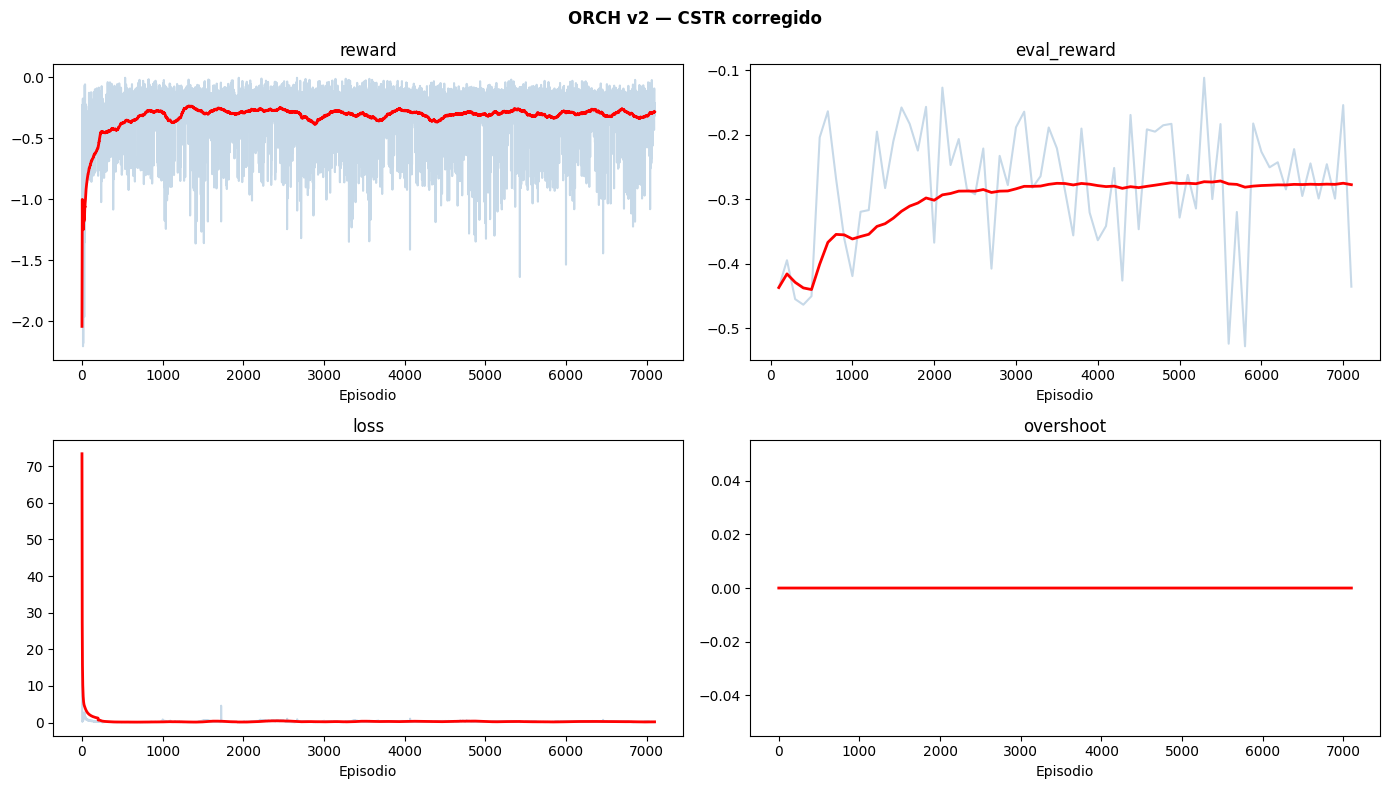

In [15]:
api = wandb.Api()
runs = api.runs('ve326684-universidad-ort-uruguay/Tesis_DQN_ORCH')
for r in runs:
    print(r.name, '|', r.id, '|', r.state)
hist = list(r.scan_history())
df = pd.DataFrame(hist)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
metricas = ['reward', 'eval_reward', 'loss', 'overshoot']

for ax, col in zip(axes.flat, metricas):
    d = df[['_step', col]].dropna()
    ax.plot(d['_step'], d[col], alpha=0.3, color='steelblue')
    ax.plot(d['_step'], d[col].rolling(200, min_periods=1).mean(), color='red', lw=2)
    ax.set_title(col)
    ax.set_xlabel('Episodio')

plt.suptitle('ORCH v2 — CSTR corregido', fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
import wandb
api = wandb.Api()

# Descargar artifact del orch
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_DQN_ORCH/model_orch_postfix_15k_v2:latest')
artifact.download(root='/content/checkpoints/orch_postfix_15k_v2/')

print(os.listdir('/content/checkpoints/orch_postfix_15k_v2/'))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb:   8 of 8 files downloaded.  


['agent_ctrl_ep4000.pt', 'agent_orch_ep2000.pt', 'agent_orch_ep4000.pt', 'agent_ctrl_ep2000.pt', 'agent_ctrl_best.pt', 'agent_ctrl_ep6000.pt', 'agent_orch_best.pt', 'agent_orch_ep6000.pt']


In [10]:
# 1. Cargar agentes
agent_ctrl = DQNAgent(state_dim=10, action_dim=7, n_vars=2, agent_role='ctrl',
                      hidden_dims=(128, 64), device='cpu', seed=42)
agent_ctrl.load('/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4/Entrenamiento/CTRL/agent_ctrl_best.pt')
agent_ctrl.epsilon = 0.0

agent_orch_v2 = DQNAgent(state_dim=5, action_dim=3, n_vars=2, agent_role='orch',
                         hidden_dims=(128, 64), device='cpu', seed=42)
agent_orch_v2.load('/content/checkpoints/orch_postfix_15k_v2/agent_orch_best.pt')
agent_orch_v2.epsilon = 0.0

# 2. Crear ambiente
env_config = {
    'architecture'        : 'jerarquica',
    'env_type'            : 'simulation',
    'n_manipulable_vars'  : 2,
    'manipulable_ranges'  : [(300, 420), (99.5, 102)],
    'n_target_vars'       : 1,
    'target_ranges'       : [(0.0, 1.0)],
    'target_setpoints'    : [0.4],
    'target_working_ranges': [(0.0, 2.0)],
    'dt_usuario'          : 1.0,
    'max_steps'           : 200,
    'max_time_detector'   : 15,
    'reward_dead_band'    : 0.02,
    'delta_percent_ctrl'  : 0.3,
    'delta_percent_orch'  : 0.1,
    'reward_weights'      : {'error': 1.0, 'tiempo': 0.3, 'overshoot': 0.2, 'energy': 0.1},
    'pid_limits'          : [(0.01, 5.0), (0.001, 1.0), (0.0001, 1.0)],
    'agent_orchestrator_config': {'agent_type': 'discrete'},
    'env_type_config'     : {'dt': 1.0, 'control_limits': ((300, 420), (99.5, 102))},
    'stability_config'    : {
        'error_increase_tolerance': 2.0,
        'max_sign_changes_ratio'  : 0.2,
        'max_abrupt_change_ratio' : 0.03,
        'abrupt_change_threshold' : 0.3,
    },
}

from Environment.PIDControlEnv_complex import PIDControlEnv_Complex
env = PIDControlEnv_Complex(env_config)
env.agente_ctrl = agent_ctrl
env.action_type_ctrl = 'discrete'

cstr = CSTRSimulator(dt=1.0, control_limits=((300, 420), (99.5, 102)))
env.proceso.connect_external_process(cstr)

print('Todo listo ✓')

Todo listo ✓


In [15]:
obs, info = env.reset()
env.current_SPs_manipulable[0] = 340.0
env.current_SPs_manipulable[1] = 102.0

# Resetear PIDs explícitamente
for pid in env.pid_controllers:
    pid.reset()

print('PIDs reseteados:')
for i, pid in enumerate(env.pid_controllers):
    print(f'  var{i}: kp={pid.kp}, ki={pid.ki}, kd={pid.kd}')

PIDs reseteados:
  var0: kp=0.05764800999999997, ki=0.13, kd=0.0001
  var1: kp=0.19882680999999994, ki=0.021849099999999993, kd=1.0


In [16]:
cstr.reset()
obs, info = env.reset()

cb_traj = [cstr.state[1]]  # usar cstr.state directamente
T_traj  = [cstr.state[3]]
V_traj  = [cstr.state[4]]
rewards_traj = []

done = False
step = 0

print(f"{'Step':<6} {'Cb':<10} {'T':<10} {'V':<10} {'Reward':<10}")
print("-" * 50)

while not done and step < 50:
    action_orch = agent_orch_v2.select_action(obs['orch'], training=False)
    action_ctrl = agent_ctrl.select_action(obs['ctrl'], training=False)
    obs, reward, terminated, truncated, info = env.step({'orch': action_orch, 'ctrl': action_ctrl})
    done = terminated or truncated

    cb_traj.append(cstr.state[1])
    T_traj.append(cstr.state[3])
    V_traj.append(cstr.state[4])
    rewards_traj.append(reward)

    print(f"{step+1:<6} {cstr.state[1]:<10.4f} {cstr.state[3]:<10.2f} "
          f"{cstr.state[4]:<10.2f} {reward:<10.3f}")
    step += 1

print(f"\nCb final: {cb_traj[-1]:.4f} | Error: {abs(cb_traj[-1]-0.4):.4f} | Reward total: {sum(rewards_traj):.2f}")

Step   Cb         T          V          Reward    
--------------------------------------------------
1      0.0630     316.54     94.50      -1.884    
2      0.0581     316.51     87.00      -1.894    
3      0.0532     316.48     79.50      -1.926    
4      0.0483     316.44     72.00      -2.011    
5      0.8418     388.88     64.50      -0.315    
6      0.8272     404.39     57.00      -0.386    
7      0.8334     404.25     49.50      -0.389    
8      0.8370     404.10     42.00      -0.397    
9      0.8364     403.90     34.50      -0.415    
10     0.8278     403.66     27.00      -0.451    
11     0.8031     403.29     19.50      -0.524    
12     0.7372     402.66     12.00      -0.690    
13     0.7035     402.38     10.00      -0.784    
14     0.7035     402.38     10.00      -0.802    
15     0.7035     402.38     10.00      -0.821    
16     0.7035     402.38     10.00      -0.839    
17     0.7035     402.38     10.00      -0.857    
18     0.7035     402.38     10

In [14]:
obs, info = env.reset()
env.current_SPs_manipulable[0] = 340.0
env.current_SPs_manipulable[1] = 102.0

for step in range(5):
    action_orch = agent_orch_v2.select_action(obs['orch'], training=False)
    action_ctrl = agent_ctrl.select_action(obs['ctrl'], training=False)

    sp_V_antes = env.current_SPs_manipulable[1]
    obs, reward, terminated, truncated, info = env.step({'orch': action_orch, 'ctrl': action_ctrl})

    print(f'Step {step+1} | action_orch={action_orch} | SP_V_antes={sp_V_antes:.2f} | SP_V_después={env.current_SPs_manipulable[1]:.2f} | V_real={cstr.state[4]:.2f}')

Step 1 | action_orch=[0 1] | SP_V_antes=102.00 | SP_V_después=99.50 | V_real=94.50
Step 2 | action_orch=[0 0] | SP_V_antes=99.50 | SP_V_después=102.00 | V_real=87.00
Step 3 | action_orch=[0 0] | SP_V_antes=102.00 | SP_V_después=102.00 | V_real=79.50
Step 4 | action_orch=[2 1] | SP_V_antes=102.00 | SP_V_después=99.50 | V_real=72.00
Step 5 | action_orch=[2 1] | SP_V_antes=99.50 | SP_V_después=99.50 | V_real=64.50


In [18]:
obs, info = env.reset()
env.current_SPs_manipulable[0] = 340.0
env.current_SPs_manipulable[1] = 102.0
for pid in env.pid_controllers:
    pid.reset()

cb_traj = [cstr.state[1]]
T_traj  = [cstr.state[3]]
V_traj  = [cstr.state[4]]
rewards_traj = []

done = False
step = 0

print(f"{'Step':<6} {'Cb':<10} {'T_sp':<8} {'T':<10} {'V':<10} {'Reward':<10}")
print("-" * 58)

while not done and step < 50:
    action_orch = agent_orch_v2.select_action(obs['orch'], training=False)
    action_ctrl = agent_ctrl.select_action(obs['ctrl'], training=False)

    # Forzar SP de V a 102 siempre
    env.current_SPs_manipulable[1] = 102.0

    sp_T = env.current_SPs_manipulable[0]

    obs, reward, terminated, truncated, info = env.step({'orch': action_orch, 'ctrl': action_ctrl})
    done = terminated or truncated

    cb_traj.append(cstr.state[1])
    T_traj.append(cstr.state[3])
    V_traj.append(cstr.state[4])
    rewards_traj.append(reward)

    print(f"{step+1:<6} {cstr.state[1]:<10.4f} {sp_T:<8.1f} {cstr.state[3]:<10.2f} {cstr.state[4]:<10.2f} {reward:<10.3f}")
    step += 1

print(f"\nCb final: {cb_traj[-1]:.4f} | Error: {abs(cb_traj[-1]-0.4):.4f} | Reward total: {sum(rewards_traj):.2f}")

Step   Cb         T_sp     T          V          Reward    
----------------------------------------------------------
1      0.0630     340.0    316.54     94.50      -0.108    
2      0.0581     306.0    316.51     87.00      -0.113    
3      0.0532     300.0    316.48     79.50      -0.120    
4      0.0483     300.0    316.44     72.00      -0.126    
5      0.0434     300.0    316.41     64.50      -0.132    
6      0.0384     300.0    316.38     57.00      -0.138    
7      0.0335     300.0    316.34     49.50      -0.144    
8      0.0284     300.0    316.31     42.00      -0.152    
9      0.0234     300.0    316.27     34.50      -0.159    
10     0.0184     300.0    316.24     27.00      -0.169    
11     0.0133     300.0    316.21     19.50      -0.199    
12     0.0082     300.0    316.17     12.00      -0.229    
13     0.0068     300.0    316.16     10.00      -0.251    
14     0.0068     300.0    316.16     10.00      -0.270    
15     0.0068     300.0    316.16     10.

In [23]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42

trainer_config = {
    'env_config': {
        'architecture'        : 'jerarquica',
        'env_type'            : 'simulation',
        'n_manipulable_vars'  : 2,
        'manipulable_ranges'  : [(300, 420), (99.5, 102)],
        'n_target_vars'       : 1,
        'target_ranges'       : [(0.0, 1.0)],
        'target_setpoints'    : [0.4],
        'target_working_ranges': [(0.0, 2.0)],
        'dt_usuario'          : 1.0,
        'max_steps'           : 50,
        'max_time_detector'   : 15,
        'reward_dead_band'    : 0.02,
        'delta_percent_ctrl'  : 0.3,
        'delta_percent_orch'  : 0.1,
        'reward_weights'      : {'error': 1.0, 'tiempo': 0.3, 'overshoot': 0.2, 'energy': 0.1},
        'pid_limits'          : [(0.01, 5.0), (0.001, 1.0), (0.0001, 1.0)],
        'agent_orchestrator_config': {'agent_type': 'discrete'},
        'env_type_config'     : {'dt': 1.0, 'control_limits': ((300, 420), (99.5, 102))},
        'stability_config'    : {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.2,
            'max_abrupt_change_ratio' : 0.03,
            'abrupt_change_threshold' : 0.3,
        },
    },
    'ctrl_checkpoint_path': '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4/Entrenamiento/CTRL/agent_ctrl_best.pt',
    'agent_ctrl_config': {
        'state_dim'  : 10,
        'action_dim' : 7,
        'n_vars'     : 2,
        'action_type': 'discrete',
        'hidden_dims': (128, 64),
        'device'     : DEVICE,
    },
    'agent_orch_config': {
        'state_dim'         : 5,
        'action_dim'        : 3,
        'n_vars'            : 2,
        'hidden_dims'       : (128, 64),
        'lr'                : 1e-4,
        'gamma'             : 0.99,
        'epsilon_start'     : 1.0,
        'epsilon_min'       : 0.01,
        'epsilon_decay'     : 0.9995,
        'batch_size'        : 32,
        'target_update_freq': 50,
        'buffer_type'       : 'priority',
        'buffer_size'       : 10000,
        'device'            : DEVICE,
        'seed'              : SEED,
    },
    'n_episodes'                 : 1,
    'eval_frequency'             : 1,
    'log_frequency'              : 1,
    'save_frequency'             : 9999,
    'checkpoint_dir'             : 'checkpoints/eval_tmp',
    'early_stopping_patience'    : 9999,
    'early_stopping_min_delta_pct': 0.01,
    'use_wandb': False,
}

trainer_eval = DQNTrainer(trainer_config)
trainer_eval.env.proceso.connect_external_process(
    CSTRSimulator(dt=1.0, control_limits=((300, 420), (99.5, 102)))
)
trainer_eval.agent_ctrl.load('/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4/Entrenamiento/CTRL/agent_ctrl_best.pt')
trainer_eval.agent_ctrl.epsilon = 0.0
trainer_eval.agent_orch.load('/content/checkpoints/orch_postfix_15k_v2/agent_orch_best.pt')
trainer_eval.agent_orch.epsilon = 0.0

reward, _ = trainer_eval._evaluate(n_eval_episodes=5)
print(f'Eval reward promedio: {reward:.4f}')

Cargando agente CTRL pre-entrenado desde: /content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4/Entrenamiento/CTRL/agent_ctrl_best.pt
Evaluación: Reward promedio = -0.49
Eval reward promedio: -0.4851


In [29]:
# Parchear _run_episode para ver Cb en cada step
import types

def _run_episode_verbose(self, episode, training=False):
    obs = self.env.reset()[0]
    state_ctrl = obs['ctrl']
    state_orch = obs['orch']

    cstr = self.env.proceso.external_process  # acceder al CSTR

    print(f"\n{'Step':<6} {'Cb':<10} {'T':<10} {'V':<10}")
    print("-" * 35)

    done = False
    step = 0
    episode_reward = 0

    while not done and step < self.max_steps_per_episode:
        action_orch = self.agent_orch.select_action(state_orch, training=False)
        action_ctrl = self.agent_ctrl.select_action(state_ctrl, training=False)
        action = {'ctrl': action_ctrl, 'orch': action_orch}

        next_obs, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated

        print(f"{step+1:<6} {cstr.state[1]:<10.4f} {cstr.state[3]:<10.2f} {cstr.state[4]:<10.2f}")

        state_ctrl = next_obs['ctrl']
        state_orch = next_obs['orch']
        episode_reward += reward
        step += 1

    print(f"\nCb final: {cstr.state[1]:.4f} | Reward: {episode_reward/step:.4f}")

trainer_eval._run_episode_verbose = types.MethodType(_run_episode_verbose, trainer_eval)
trainer_eval._run_episode_verbose(episode=0, training=False)


Step   Cb         T          V         
-----------------------------------
1      0.0630     316.54     94.50     
2      0.8520     385.37     87.00     
3      0.8012     404.73     79.50     
4      0.8263     383.50     72.00     
5      0.2805     343.03     64.50     
6      0.7025     372.06     57.00     
7      0.8334     404.25     49.50     
8      0.6571     373.34     42.00     
9      0.8364     403.90     34.50     
10     0.8278     403.66     27.00     
11     0.8031     403.29     19.50     
12     0.6419     393.33     12.00     
13     0.7035     402.38     10.00     
14     0.4083     379.56     10.00     
15     0.0460     340.16     10.00     
16     0.2542     368.19     10.00     
17     0.7035     402.38     10.00     
18     0.7035     402.38     10.00     
19     0.7035     402.38     10.00     
20     0.7035     402.38     10.00     
21     0.7035     402.38     10.00     
22     0.7035     402.38     10.00     
23     0.7035     402.38     10.00     
24 

In [28]:
print(dir(trainer_eval.env.proceso))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'connect_external_process', 'dt_sim', 'external_process', 'get_state', 'get_target_values', 'manipulable_pvs', 'manipulable_ranges', 'n_manipulable_vars', 'reset', 'simulate_step_multi']
